# The Guide to Inferential Statistics in Python

This notebook covers the complete workflow for inferential statistics, from basic T-tests to advanced modeling and survival analysis.

**Table of Contents:**
1.  **Setup:** Data Generation (Continuous, Categorical, Time-to-Event).
2.  **Descriptive Stats:** Normality Checks (The Bell Curve).
3.  **Comparison of Means:**
    * One-Sample Tests (vs Known Value)
    * Two Independent Groups (T-Test / Mann-Whitney) + **Effect Size (Cohen's d)**
    * Paired Groups (Before vs After)
4.  **Analysis of Variance (ANOVA):**
    * One-Way ANOVA + **Post-Hoc Testing (Tukey's HSD)**
    * **Two-Way ANOVA** (Interaction Effects)
5.  **Regression & Classification:**
    * Linear Regression (Predicting Values)
    * **Logistic Regression** (Predicting Probabilities/Categories)
6.  **Categorical Analysis:** Chi-Square Test.
7.  **Planning:** **Power Analysis** (Sample Size Calculation).
8.  **Time-to-Event:** **Survival Analysis** (Kaplan-Meier).

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.stats.multicomp as mc # For Tukey Post-Hoc
from statsmodels.formula.api import ols, logit # For ANOVA/Logistic
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
np.random.seed(42)

# --- Generate Comprehensive Mock Data ---
N = 200
data = pd.DataFrame({
    # Continuous Data (Normal & Skewed)
    'group_a': np.random.normal(loc=50, scale=10, size=N),
    'group_b': np.random.normal(loc=55, scale=10, size=N),
    'group_c': np.random.normal(loc=42, scale=12, size=N),
    'skewed_data': np.random.exponential(scale=10, size=N),
    
    # Paired Data
    'bp_before': np.random.normal(loc=120, scale=10, size=N),
    'bp_after': np.random.normal(loc=115, scale=10, size=N),
    
    # Regression Data
    'experience_yrs': np.random.uniform(1, 20, size=N),
    
    # Logistic Regression Data (Study Hours -> Pass/Fail)
    'study_hours': np.random.uniform(1, 15, size=N),
    
    # Factors for ANOVA
    'teaching_method': np.random.choice(['Online', 'In-Person'], size=N),
    'classroom': np.random.choice(['Room A', 'Room B', 'Room C'], size=N),
    
    # Survival Analysis Data (Time to Event)
    'months_subscribed': np.random.exponential(scale=12, size=N), # Time
    'churn_event': np.random.binomial(1, 0.7, size=N) # 1=Churned, 0=Still Subscribed
})

# Feature Engineering
# 1. Linear relationship for Salary
data['salary'] = 40000 + (data['experience_yrs'] * 3000) + np.random.normal(0, 5000, N)

# 2. Logistic relationship for Pass/Fail (Sigmoid)
log_odds = -5 + (0.8 * data['study_hours'])
prob_pass = 1 / (1 + np.exp(-log_odds))
data['passed_exam'] = np.random.binomial(1, prob_pass) # 1=Pass, 0=Fail

print("Complex Dataset Generated Successfully.")
display(data.head())

Complex Dataset Generated Successfully.


,group_a,group_b,group_c,skewed_data,bp_before,bp_after,experience_yrs,study_hours,teaching_method,classroom,months_subscribed,churn_event,salary,passed_exam
0,54.967142,58.577874,22.866868,2.603930,114.243622,121.427228,10.862554,14.521510,In-Person,Room C,4.220075,1,74921.289091,1
1,48.617357,60.607845,34.807500,12.810431,121.220098,128.291525,10.104456,7.054970,In-Person,Room C,30.042910,0,72743.178440,0
2,56.476885,65.830512,42.062924,12.730962,145.600845,116.965212,1.487199,5.365426,In-Person,Room C,1.408501,1,46207.460453,0
3,65.230299,65.538021,42.563767,10.248442,119.039401,122.090038,7.483709,8.085986,In-Person,Room B,17.104535,1,65806.311238,1
4,47.658466,41.223306,36.599214,11.840017,131.492733,114.102643,8.223717,7.153164,In-Person,Room B,53.139930,0,63558.441091,1


---
###  1. Descriptive Statistics & Normality Checks
Before testing, we check if data follows a Normal Distribution (Bell Curve) to decide between Parametric and Non-Parametric tests.

--- Group A (Normal) ---
Shapiro-Wilk p-value: 0.82899
Result: Normal Distribution (Use Parametric)


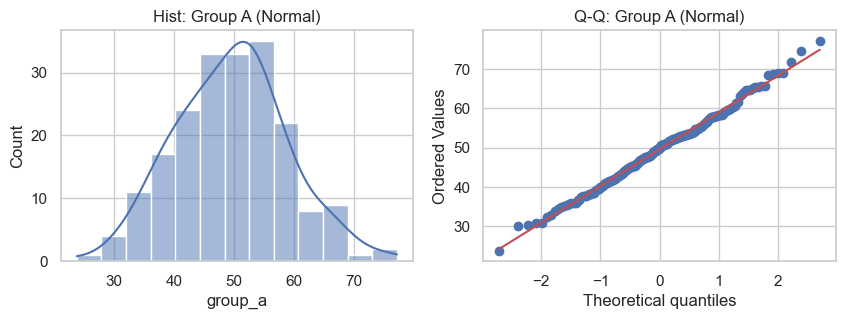

--- Exponential Data (Skewed) ---
Shapiro-Wilk p-value: 0.00000
Result: Not Normal (Use Non-Parametric)


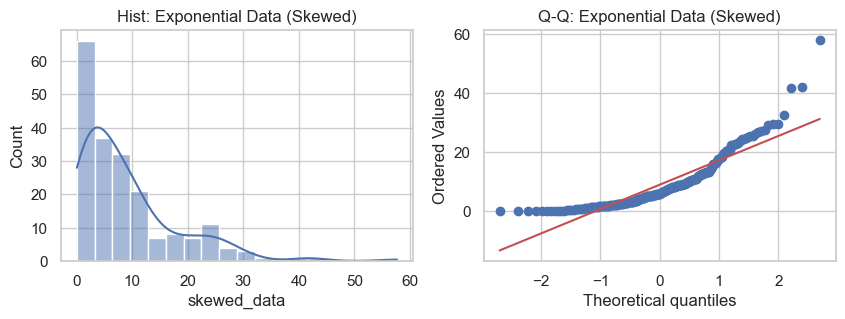

In [2]:
def check_normality(data, name):
    stat, p = stats.shapiro(data)
    print(f"--- {name} ---")
    print(f"Shapiro-Wilk p-value: {p:.5f}")
    if p > 0.05: print("Result: Normal Distribution (Use Parametric)")
    else: print("Result: Not Normal (Use Non-Parametric)")
    
    # Visual check
    plt.figure(figsize=(10, 3))
    plt.subplot(1, 2, 1); sns.histplot(data, kde=True); plt.title(f'Hist: {name}')
    plt.subplot(1, 2, 2); stats.probplot(data, dist="norm", plot=plt); plt.title(f'Q-Q: {name}')
    plt.show()

check_normality(data['group_a'], "Group A (Normal)")
check_normality(data['skewed_data'], "Exponential Data (Skewed)")

---
### 2. Comparison of Means & Effect Size
**New Addition: Cohen's d.** Statistical significance (p-value) tells you *if* there is a difference. Effect size (Cohen's d) tells you *how big* the difference is.
* **Small effect:** ~0.2
* **Medium effect:** ~0.5
* **Large effect:** ~0.8+

Independent T-Test: p-value = 0.00000
Cohen's d (Effect Size): -0.655
Interpretation: Medium Effect


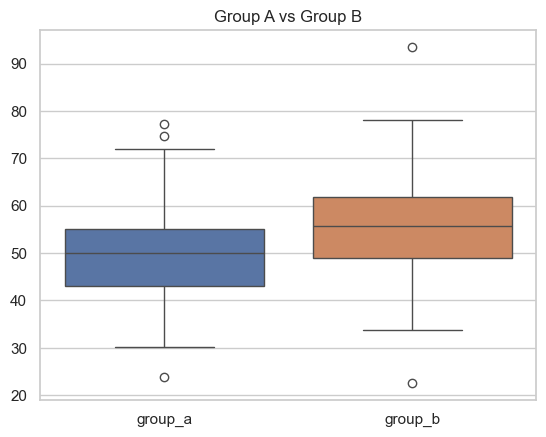

In [3]:
# --- 1. Independent T-Test ---
t_stat, p_val = stats.ttest_ind(data['group_a'], data['group_b'])

# --- 2. Calculate Cohen's d (Effect Size) ---
mean_diff = np.mean(data['group_a']) - np.mean(data['group_b'])
pooled_std = np.sqrt((np.std(data['group_a'])**2 + np.std(data['group_b'])**2) / 2)
cohens_d = mean_diff / pooled_std

print(f"Independent T-Test: p-value = {p_val:.5f}")
print(f"Cohen's d (Effect Size): {cohens_d:.3f}")
if abs(cohens_d) > 0.8: print("Interpretation: Large Effect")
elif abs(cohens_d) > 0.5: print("Interpretation: Medium Effect")
else: print("Interpretation: Small Effect")

# Visual
sns.boxplot(data=data[['group_a', 'group_b']])
plt.title("Group A vs Group B")
plt.show()

---
### 3. ANOVA & Post-Hoc Tests
**One-Way ANOVA** tells us if *at least one* group is different.
**Tukey's HSD (Post-Hoc)** tells us exactly *which* groups differ.

**Two-Way ANOVA** tests two factors at once (e.g., Classroom AND Teaching Method) and their interaction.

In [4]:
print("--- 1. One-Way ANOVA ---")
f_stat, p_val = stats.f_oneway(data['group_a'], data['group_b'], data['group_c'])
print(f"ANOVA p-value: {p_val:.5f} (Significant difference exists)")

print("\n--- 2. Tukey's HSD Post-Hoc Test ---")
# Melt data for statsmodels
melted = pd.melt(data[['group_a', 'group_b', 'group_c']], var_name='Group', value_name='Score')
tukey = mc.MultiComparison(melted['Score'], melted['Group'])
tukey_result = tukey.tukeyhsd()
print(tukey_result)

print("\n--- 3. Two-Way ANOVA (Interaction Effects) ---")
# Does score depend on Classroom AND Teaching Method?
# Model: Score ~ C(Classroom) + C(Method) + C(Classroom):C(Method)
model = ols('group_a ~ C(classroom) + C(teaching_method) + C(classroom):C(teaching_method)', data=data).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

--- 1. One-Way ANOVA ---
ANOVA p-value: 0.00000 (Significant difference exists)

--- 2. Tukey's HSD Post-Hoc Test ---
  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj  lower    upper   reject
-------------------------------------------------------
group_a group_b   6.2664   0.0   3.8157   8.7171   True
group_a group_c  -8.6202   0.0 -11.0709  -6.1694   True
group_b group_c -14.8865   0.0 -17.3373 -12.4358   True
-------------------------------------------------------

--- 3. Two-Way ANOVA (Interaction Effects) ---
                                       sum_sq     df         F    PR(>F)
C(classroom)                        78.273336    2.0  0.444622  0.641718
C(teaching_method)                  90.586371    1.0  1.029130  0.311627
C(classroom):C(teaching_method)     13.475248    2.0  0.076545  0.926340
Residual                         17076.322168  194.0       NaN       NaN


---
### 4. Regression & Classification
**Linear Regression:** Predicts a continuous value (Salary).
**Logistic Regression:** Predicts a binary category (Pass/Fail). This is crucial for classification problems.

Linear Regression R-squared: 0.921

--- Logistic Regression Summary ---
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -5.1953      0.774     -6.713      0.000      -6.712      -3.678
study_hours     0.8124      0.112      7.228      0.000       0.592       1.033


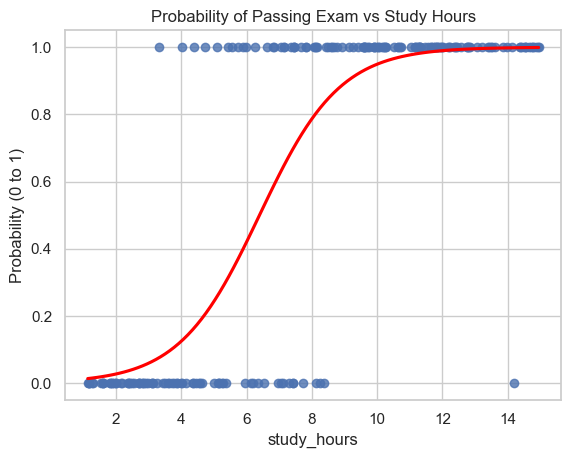

In [5]:
# --- Linear Regression (Salary Prediction) ---
slope, intercept, r_value, _, _ = stats.linregress(data['experience_yrs'], data['salary'])
print(f"Linear Regression R-squared: {r_value**2:.3f}")

# --- Logistic Regression (Pass/Fail Prediction) ---
# Predicting 'passed_exam' (0 or 1) using 'study_hours'
log_reg = sm.Logit(data['passed_exam'], sm.add_constant(data['study_hours'])).fit(disp=0)

print("\n--- Logistic Regression Summary ---")
print(log_reg.summary().tables[1])

# Visualizing the Sigmoid Curve
sns.regplot(x='study_hours', y='passed_exam', data=data, logistic=True, ci=None, line_kws={'color': 'red'})
plt.title("Probability of Passing Exam vs Study Hours")
plt.ylabel("Probability (0 to 1)")
plt.show()

---
### 5. Power Analysis (Sample Size Calculation)
Before running a study, we must ask: "How many samples do I need?"
* **Alpha:** 0.05 (Standard significance level)
* **Power:** 0.80 (Standard probability of detecting an effect if it exists)
* **Effect Size:** Expected magnitude of difference.

--- Sample Size Calculation ---
To detect a medium effect (0.5) with 80% power, you need:
64 observations per group.


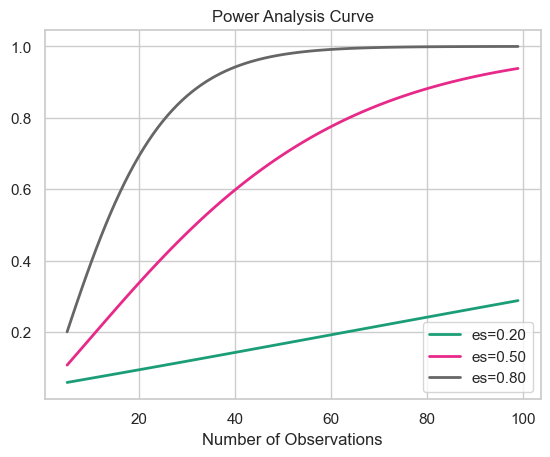

In [6]:
from statsmodels.stats.power import TTestIndPower

# Parameters
effect_size = 0.5  # Medium effect
alpha = 0.05       # 5% chance of false positive
power = 0.80       # 80% chance of detecting the effect

analysis = TTestIndPower()
sample_size = analysis.solve_power(effect_size=effect_size, power=power, alpha=alpha)

print(f"--- Sample Size Calculation ---")
print(f"To detect a medium effect (0.5) with 80% power, you need:")
print(f"{int(np.ceil(sample_size))} observations per group.")

# Plot Power Curve
analysis.plot_power(dep_var='nobs', nobs=np.arange(5, 100), effect_size=np.array([0.2, 0.5, 0.8]))
plt.title("Power Analysis Curve")
plt.show()

---
### 6. Survival Analysis (Time-to-Event)
Used when the outcome is **"Time until an event"** (e.g., Customer Churn, Machine Failure).
We use the **Kaplan-Meier Estimator** to visualize the survival probability over time.

<Figure size 800x500 with 0 Axes>

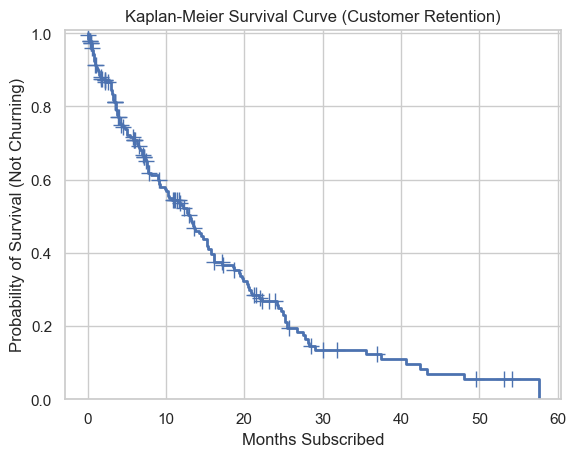

Median Survival Time: 13.0 months


In [8]:
# Note: For professional survival analysis, 'lifelines' library is recommended.
# Here we use statsmodels to keep dependencies standard.

from statsmodels.duration.survfunc import SurvfuncRight

# 'months_subscribed' is time, 'churn_event' is the event (1=Churned, 0=Censored/Active)
surv = SurvfuncRight(data['months_subscribed'], data['churn_event'])

# Plot
plt.figure(figsize=(8, 5))
surv.plot()
plt.title("Kaplan-Meier Survival Curve (Customer Retention)")
plt.xlabel("Months Subscribed")
plt.ylabel("Probability of Survival (Not Churning)")
plt.grid(True)
plt.show()

print(f"Median Survival Time: {surv.quantile(0.5):.1f} months")